In [48]:
import pandas as pd

# Charger les 2 datasets
results = pd.read_csv('../data/raw/results.csv')
rankings = pd.read_csv('../data/raw/fifa_ranking-2024-06-20.csv')

# Premier coup d'oeil
print("RESULTS:")
print(results.head())
print(results.shape)

print("\nRANKINGS:")
print(rankings.head())
print(rankings.shape)

RESULTS:
         date home_team away_team  home_score  away_score tournament     city  \
0  1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow   
1  1873-03-08   England  Scotland         4.0         2.0   Friendly   London   
2  1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow   
3  1875-03-06   England  Scotland         2.0         2.0   Friendly   London   
4  1876-03-04  Scotland   England         3.0         0.0   Friendly  Glasgow   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  
3   England    False  
4  Scotland    False  
(49509, 9)

RANKINGS:
    rank       country_full country_abrv  total_points  previous_points  \
0  140.0  Brunei Darussalam          BRU           2.0              0.0   
1   33.0           Portugal          POR          38.0              0.0   
2   32.0             Zambia          ZAM          38.0              0.0   
3   31.0             Greece          GRE    

In [49]:
check = pd.read_csv('../data/raw/fifa_ranking-2024-06-20.csv')
print(check.columns.tolist())
print(check['rank_date'].unique() if 'rank_date' in check.columns else "pas de colonne rank_date")
print(check.shape)

['rank', 'country_full', 'country_abrv', 'total_points', 'previous_points', 'rank_change', 'confederation', 'rank_date']
<StringArray>
['1992-12-31', '1993-08-08', '1993-09-23', '1993-10-22', '1993-11-19',
 '1993-12-23', '1994-02-15', '1994-03-15', '1994-04-19', '1994-05-17',
 ...
 '2023-04-06', '2023-06-29', '2023-07-20', '2023-09-21', '2023-10-26',
 '2023-11-30', '2023-12-21', '2024-02-15', '2024-04-04', '2024-06-20']
Length: 333, dtype: str
(67472, 8)


In [50]:
print(results.columns.tolist())
print(results.head())
print(results.shape)

['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']
         date home_team away_team  home_score  away_score tournament     city  \
0  1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow   
1  1873-03-08   England  Scotland         4.0         2.0   Friendly   London   
2  1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow   
3  1875-03-06   England  Scotland         2.0         2.0   Friendly   London   
4  1876-03-04  Scotland   England         3.0         0.0   Friendly  Glasgow   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  
3   England    False  
4  Scotland    False  
(49509, 9)


## DATA CLEANING

In [51]:
results['date'] = pd.to_datetime(results['date'])
rankings['rank_date'] = pd.to_datetime(rankings['rank_date'])

In [52]:
results = results.sort_values('date').reset_index(drop=True)
rankings = rankings.sort_values('rank_date').reset_index(drop=True)

In [53]:
teams_results = set(results['home_team'].unique()) | set(results['away_team'].unique())
teams_rankings = set(rankings['country_full'].unique())

# Noms présents dans results mais absents de rankings
missing = teams_results - teams_rankings
print(f"Nombre d'équipes sans correspondance: {len(missing)}")
# Filtrer les NaN avant de trier
missing_clean = {x for x in missing if isinstance(x, str)}
print(f"Nombre d'équipes sans correspondance: {len(missing_clean)}")
print(sorted(missing_clean))

# Vérifier s'il y avait bien des NaN
nan_count = len(missing) - len(missing_clean)
print(f"\nValeurs NaN trouvées: {nan_count}")

Nombre d'équipes sans correspondance: 143
Nombre d'équipes sans correspondance: 142
['Abkhazia', 'Alderney', 'Ambazonia', 'Andalusia', 'Arameans Suryoye', 'Artsakh', 'Asturias', 'Aymara', 'Barawa', 'Basque Country', 'Biafra', 'Bonaire', 'Brittany', 'Brunei', 'Canary Islands', 'Cape Verde', 'Cascadia', 'Catalonia', 'Central Spain', 'Chagos Islands', 'Chameria', 'Chechnya', 'China', 'Cilento', 'Corsica', 'County of Nice', 'Crimea', 'Curaçao', 'Czech Republic', 'DR Congo', 'Darfur', 'Donetsk PR', 'Délvidék', 'East Turkestan', 'Elba Island', 'Ellan Vannin', 'Falkland Islands', 'Felvidék', 'Franconia', 'French Guiana', 'Frøya', 'Galicia', 'Gambia', 'German DR', 'Gotland', 'Gozo', 'Greenland', 'Guadeloupe', 'Guernsey', 'Găgăuzia', 'Hitra', 'Hmong', 'Iran', 'Iraqi Kurdistan', 'Isle of Man', 'Isle of Wight', 'Ivory Coast', 'Jersey', 'Kabylia', 'Kernow', 'Kiribati', 'Kurdistan', 'Kyrgyzstan', 'Kárpátalja', 'Luhansk PR', 'Madrid', 'Manchukuo', 'Mapuche', 'Marshall Islands', 'Martinique', 'Matabe

In [54]:
name_mapping = {
    'United States': 'USA',
    'South Korea': 'Korea Republic',
    'North Korea': 'Korea DPR',
    "Ivory Coast": "Côte d'Ivoire",
    'Czech Republic': 'Czechia',
    'DR Congo': 'Congo DR',  # corrigé
    'Iran': 'IR Iran',
    'Gambia': 'The Gambia',
    'Cape Verde': 'Cabo Verde',
    'Brunei': 'Brunei Darussalam',
    'Taiwan': 'Chinese Taipei',
    'China': 'China PR',
    'Saint Kitts and Nevis': 'St Kitts and Nevis',
    'Saint Lucia': 'St Lucia',
    'Saint Vincent and the Grenadines': 'St Vincent and the Grenadines',  # corrigé
    'Kyrgyzstan': 'Kyrgyz Republic',
}

# Ré-appliquer le mapping corrigé
results['home_team'] = results['home_team'].replace(name_mapping)
results['away_team'] = results['away_team'].replace(name_mapping)

In [55]:
teams_results_v3 = set(results['home_team'].unique()) | set(results['away_team'].unique())
still_missing_v2 = {x for x in (teams_results_v3 - teams_rankings) if isinstance(x, str)}
print(f"Restant après mapping corrigé: {len(still_missing_v2)}")

Restant après mapping corrigé: 126


In [56]:
print('Spain' in teams_rankings, 'Argentina' in teams_rankings)
print('Spain' in teams_results_v3, 'Argentina' in teams_results_v3)

True True
True True


In [57]:
# Sécurité : reconvertir les dates si pas encore fait
results['date'] = pd.to_datetime(results['date'])
rankings['rank_date'] = pd.to_datetime(rankings['rank_date'])

# Trier (obligatoire pour merge_asof)
results = results.sort_values('date').reset_index(drop=True)
rankings = rankings.sort_values('rank_date').reset_index(drop=True)

# Merge pour l'équipe à domicile (home_team)
df = pd.merge_asof(
    results,
    rankings[['rank_date', 'country_full', 'rank', 'total_points']],
    left_on='date', right_on='rank_date',
    left_by='home_team', right_by='country_full',
    direction='backward'
).rename(columns={'rank': 'home_rank', 'total_points': 'home_points'})

df = df.drop(columns=['rank_date', 'country_full'])

# Merge pour l'équipe à l'extérieur (away_team)
df = pd.merge_asof(
    df,
    rankings[['rank_date', 'country_full', 'rank', 'total_points']],
    left_on='date', right_on='rank_date',
    left_by='away_team', right_by='country_full',
    direction='backward'
).rename(columns={'rank': 'away_rank', 'total_points': 'away_points'})

df = df.drop(columns=['rank_date', 'country_full'])

print(df.shape)
print(df.head())
print(df.isnull().sum())

(49509, 13)
        date home_team away_team  home_score  away_score tournament     city  \
0 1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow   
1 1873-03-08   England  Scotland         4.0         2.0   Friendly   London   
2 1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow   
3 1875-03-06   England  Scotland         2.0         2.0   Friendly   London   
4 1876-03-04  Scotland   England         3.0         0.0   Friendly  Glasgow   

    country  neutral  home_rank  home_points  away_rank  away_points  
0  Scotland    False        NaN          NaN        NaN          NaN  
1   England    False        NaN          NaN        NaN          NaN  
2  Scotland    False        NaN          NaN        NaN          NaN  
3   England    False        NaN          NaN        NaN          NaN  
4  Scotland    False        NaN          NaN        NaN          NaN  
date               0
home_team          2
away_team          2
home_score        

In [58]:
# Vérifier les lignes avec équipes ou scores manquants
print(df[df['home_team'].isnull() | df['away_team'].isnull()])
print(df[df['home_score'].isnull() | df['away_score'].isnull()])

            date home_team away_team  home_score  away_score      tournament  \
49507 2026-07-18       NaN       NaN         NaN         NaN  FIFA World Cup   
49508 2026-07-19       NaN       NaN         NaN         NaN  FIFA World Cup   

                  city        country  neutral  home_rank  home_points  \
49507    Miami Gardens  United States     True        NaN          NaN   
49508  East Rutherford  United States     True        NaN          NaN   

       away_rank  away_points  
49507        NaN          NaN  
49508        NaN          NaN  
            date home_team  away_team  home_score  away_score      tournament  \
49505 2026-07-14    France      Spain         NaN         NaN  FIFA World Cup   
49506 2026-07-15   England  Argentina         NaN         NaN  FIFA World Cup   
49507 2026-07-18       NaN        NaN         NaN         NaN  FIFA World Cup   
49508 2026-07-19       NaN        NaN         NaN         NaN  FIFA World Cup   

                  city        coun

In [59]:
# Dropper les lignes complètement vides (les 2 placeholders sans équipes)
df = df.dropna(subset=['home_team', 'away_team'])

print(f"Shape après suppression des placeholders vides: {df.shape}")

Shape après suppression des placeholders vides: (49507, 13)


In [60]:
# Garder uniquement les matchs avec ranking FIFA connu ET un score
df_clean = df.dropna(subset=['home_rank', 'away_rank', 'home_score', 'away_score'])

print(f"Avant filtrage: {df.shape}")
print(f"Après filtrage: {df_clean.shape}")
print(df_clean['date'].min(), "->", df_clean['date'].max())

Avant filtrage: (49507, 13)
Après filtrage: (28321, 13)
1993-01-01 00:00:00 -> 2026-07-11 00:00:00


## FEATURE ENGINEERING

In [61]:
# Feature de base : différence de classement et de points FIFA
df_clean = df_clean.copy()  # éviter le warning pandas
df_clean['rank_diff'] = df_clean['away_rank'] - df_clean['home_rank']
df_clean['points_diff'] = df_clean['home_points'] - df_clean['away_points']

# Target : qui a gagné ? (1 = victoire home, 0 = victoire away, on garde de côté les nuls pour l'instant)
df_clean['home_win'] = (df_clean['home_score'] > df_clean['away_score']).astype(int)
df_clean['away_win'] = (df_clean['away_score'] > df_clean['home_score']).astype(int)
df_clean['draw'] = (df_clean['home_score'] == df_clean['away_score']).astype(int)

print(df_clean[['home_team', 'away_team', 'rank_diff', 'points_diff', 'home_win', 'away_win', 'draw']].head(10))
print("\nRépartition:")
print(f"Victoires home: {df_clean['home_win'].sum()}")
print(f"Victoires away: {df_clean['away_win'].sum()}")
print(f"Nuls: {df_clean['draw'].sum()}")

          home_team     away_team  rank_diff  points_diff  home_win  away_win  \
18708         Ghana          Mali       30.0         12.0         0         0   
18709         Gabon  Burkina Faso       42.0         16.0         0         0   
18710        Kuwait       Lebanon       90.0         21.0         1         0   
18711  Burkina Faso          Mali      -28.0        -11.0         1         0   
18712         Gabon         Ghana      -16.0         -7.0         0         1   
18713        Uganda      Tanzania      -12.0         -3.0         1         0   
18714        Angola      Zimbabwe      -48.0        -17.0         0         0   
18715      Botswana  South Africa      -15.0         -3.0         0         1   
18717       Senegal       Algeria      -21.0        -12.0         0         1   
18718       Tunisia      Bulgaria      -12.0         -6.0         1         0   

       draw  
18708     1  
18709     1  
18710     0  
18711     0  
18712     0  
18713     0  
18714     

In [62]:
# D'abord, on construit un historique "long format" : une ligne par équipe par match
home_df = df_clean[['date', 'home_team', 'home_win', 'draw', 'away_win']].copy()
home_df.columns = ['date', 'team', 'win', 'draw', 'loss']

away_df = df_clean[['date', 'away_team', 'away_win', 'draw', 'home_win']].copy()
away_df.columns = ['date', 'team', 'win', 'draw', 'loss']

team_history = pd.concat([home_df, away_df]).sort_values(['team', 'date']).reset_index(drop=True)

print(team_history.head(10))
print(team_history.shape)

        date         team  win  draw  loss
0 2003-03-16  Afghanistan    1     0     0
1 2003-03-18  Afghanistan    0     0     1
2 2003-11-19  Afghanistan    0     0     1
3 2003-11-23  Afghanistan    0     0     1
4 2005-11-09  Afghanistan    0     0     1
5 2005-12-07  Afghanistan    0     0     1
6 2005-12-09  Afghanistan    0     0     1
7 2005-12-11  Afghanistan    1     0     0
8 2006-04-03  Afghanistan    0     1     0
9 2006-04-05  Afghanistan    0     1     0
(56642, 5)


## ROLLING AVERAAGE

In [63]:
# Pour chaque équipe, calculer le nombre de victoires sur les 5 derniers matchs (avant le match actuel)
team_history['win_last5'] = (
    team_history.groupby('team')['win']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).sum())
)

team_history['loss_last5'] = (
    team_history.groupby('team')['loss']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).sum())
)

print(team_history[team_history['team'] == 'Afghanistan'].head(12))

         date         team  win  draw  loss  win_last5  loss_last5
0  2003-03-16  Afghanistan    1     0     0        NaN         NaN
1  2003-03-18  Afghanistan    0     0     1        1.0         0.0
2  2003-11-19  Afghanistan    0     0     1        1.0         1.0
3  2003-11-23  Afghanistan    0     0     1        1.0         2.0
4  2005-11-09  Afghanistan    0     0     1        1.0         3.0
5  2005-12-07  Afghanistan    0     0     1        1.0         4.0
6  2005-12-09  Afghanistan    0     0     1        0.0         5.0
7  2005-12-11  Afghanistan    1     0     0        0.0         5.0
8  2006-04-03  Afghanistan    0     1     0        1.0         4.0
9  2006-04-05  Afghanistan    0     1     0        1.0         3.0
10 2007-10-08  Afghanistan    0     0     1        1.0         2.0
11 2007-10-26  Afghanistan    0     0     1        1.0         2.0


In [64]:
# Merge pour l'équipe home
df_clean = df_clean.merge(
    team_history[['date', 'team', 'win_last5', 'loss_last5']],
    left_on=['date', 'home_team'], right_on=['date', 'team'],
    how='left'
).rename(columns={'win_last5': 'home_form_win', 'loss_last5': 'home_form_loss'}).drop(columns=['team'])

# Merge pour l'équipe away
df_clean = df_clean.merge(
    team_history[['date', 'team', 'win_last5', 'loss_last5']],
    left_on=['date', 'away_team'], right_on=['date', 'team'],
    how='left'
).rename(columns={'win_last5': 'away_form_win', 'loss_last5': 'away_form_loss'}).drop(columns=['team'])

print(df_clean.shape)
print(df_clean[['home_team', 'away_team', 'home_form_win', 'home_form_loss', 'away_form_win', 'away_form_loss']].head(10))
print(df_clean.isnull().sum())

(28345, 22)
      home_team     away_team  home_form_win  home_form_loss  away_form_win  \
0         Ghana          Mali            NaN             NaN            NaN   
1         Gabon  Burkina Faso            NaN             NaN            NaN   
2        Kuwait       Lebanon            NaN             NaN            NaN   
3  Burkina Faso          Mali            0.0             0.0            0.0   
4         Gabon         Ghana            0.0             0.0            0.0   
5        Uganda      Tanzania            NaN             NaN            NaN   
6        Angola      Zimbabwe            NaN             NaN            NaN   
7      Botswana  South Africa            NaN             NaN            NaN   
8       Senegal       Algeria            NaN             NaN            NaN   
9       Tunisia      Bulgaria            NaN             NaN            NaN   

   away_form_loss  
0             NaN  
1             NaN  
2             NaN  
3             0.0  
4             0.0 

In [65]:
# Vérifier s'il y a des vrais doublons de lignes après le merge
duplicates = df_clean[df_clean.duplicated(subset=['date', 'home_team', 'away_team'], keep=False)]
print(duplicates.shape)
print(duplicates[['date', 'home_team', 'away_team', 'home_score', 'away_score']].head(20))

(44, 22)
            date    home_team         away_team  home_score  away_score
1287  1995-03-25     Pakistan        Bangladesh         1.0         0.0
1288  1995-03-25     Pakistan        Bangladesh         1.0         0.0
1289  1995-03-25        Nepal        Bangladesh         0.0         2.0
1290  1995-03-25        Nepal        Bangladesh         0.0         2.0
5563  2000-09-03     China PR              Iraq         4.0         1.0
5564  2000-09-03     China PR              Iraq         4.0         1.0
5573  2000-09-03    Indonesia              Iraq         3.0         0.0
5574  2000-09-03    Indonesia              Iraq         3.0         0.0
5829  2001-01-17       Israel        Uzbekistan         2.0         0.0
5830  2001-01-17       Israel        Uzbekistan         2.0         0.0
5832  2001-01-17        Chile        Uzbekistan         2.0         0.0
5833  2001-01-17        Chile        Uzbekistan         2.0         0.0
13853 2010-05-30        Chile  Northern Ireland        

In [66]:
df_clean = df_clean.drop_duplicates(subset=['date', 'home_team', 'away_team', 'home_score', 'away_score'])
print(df_clean.shape)  # devrait revenir à ~28183

(28320, 22)


In [67]:
df_clean[['home_form_win', 'home_form_loss', 'away_form_win', 'away_form_loss']] = (
    df_clean[['home_form_win', 'home_form_loss', 'away_form_win', 'away_form_loss']].fillna(0)
)

print(df_clean.isnull().sum())

date              0
home_team         0
away_team         0
home_score        0
away_score        0
tournament        0
city              0
country           0
neutral           0
home_rank         0
home_points       0
away_rank         0
away_points       0
rank_diff         0
points_diff       0
home_win          0
away_win          0
draw              0
home_form_win     0
home_form_loss    0
away_form_win     0
away_form_loss    0
dtype: int64


In [68]:
# On crée une clé unique par paire d'équipes (peu importe l'ordre home/away)
df_clean['match_key'] = df_clean.apply(
    lambda row: '_'.join(sorted([row['home_team'], row['away_team']])), axis=1
)

# Fonction pour calculer le h2h win rate avant chaque match
def compute_h2h(df):
    h2h_home_wins = []
    h2h_total = []
    
    history = {}  # clé: match_key, valeur: liste des résultats passés (du point de vue de l'équipe qui était "home" à chaque fois)
    
    for idx, row in df.iterrows():
        key = row['match_key']
        past_matches = history.get(key, [])
        
        # Compter combien de fois l'équipe actuellement "home" a gagné dans le passé (qu'elle ait été home ou away à l'époque)
        home_team = row['home_team']
        wins_home_team = sum(1 for m in past_matches if m['winner'] == home_team)
        total = len(past_matches)
        
        h2h_home_wins.append(wins_home_team)
        h2h_total.append(total)
        
        # Enregistrer le résultat de ce match pour le futur
        if row['home_win'] == 1:
            winner = row['home_team']
        elif row['away_win'] == 1:
            winner = row['away_team']
        else:
            winner = None  # nul
        
        past_matches.append({'winner': winner})
        history[key] = past_matches
    
    df['h2h_home_wins'] = h2h_home_wins
    df['h2h_total_matches'] = h2h_total
    return df

df_clean = df_clean.sort_values('date').reset_index(drop=True)
df_clean = compute_h2h(df_clean)

# Calculer le win rate (éviter division par zéro)
df_clean['h2h_win_rate'] = df_clean.apply(
    lambda row: row['h2h_home_wins'] / row['h2h_total_matches'] if row['h2h_total_matches'] > 0 else 0.5, axis=1
)

print(df_clean[['date', 'home_team', 'away_team', 'h2h_total_matches', 'h2h_win_rate']].tail(15))

            date    home_team    away_team  h2h_total_matches  h2h_win_rate
28305 2026-07-03     Colombia        Ghana                  0      0.500000
28306 2026-07-03    Australia        Egypt                  1      0.000000
28307 2026-07-03    Argentina   Cabo Verde                  0      0.500000
28308 2026-07-04       Canada      Morocco                  3      0.000000
28309 2026-07-04     Paraguay       France                  4      0.000000
28310 2026-07-05       Brazil       Norway                  3      0.000000
28311 2026-07-05       Mexico      England                  3      0.000000
28312 2026-07-06     Portugal        Spain                 13      0.153846
28313 2026-07-06          USA      Belgium                  6      0.000000
28314 2026-07-07    Argentina        Egypt                  1      1.000000
28315 2026-07-07  Switzerland     Colombia                  2      0.000000
28316 2026-07-09       France      Morocco                  5      0.600000
28317 2026-0

In [78]:
# Split chronologique : on entraîne sur le passé, on teste sur le plus récent
df_clean = df_clean.sort_values('date').reset_index(drop=True)

split_index = int(len(df_clean) * 0.8)
train = df_clean.iloc[:split_index]
test = df_clean.iloc[split_index:]

print(f"Train: {train.shape}, de {train['date'].min()} à {train['date'].max()}")
print(f"Test: {test.shape}, de {test['date'].min()} à {test['date'].max()}")

Train: (22656, 26), de 1993-01-01 00:00:00 à 2020-10-11 00:00:00
Test: (5664, 26), de 2020-10-11 00:00:00 à 2026-07-11 00:00:00


# FEATURES AND TARGET DEFINITION

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report

# Les features qu'on utilise pour prédire
features = ['rank_diff', 'points_diff', 'home_form_win', 'home_form_loss', 
            'away_form_win', 'away_form_loss', 'neutral', 'h2h_win_rate']

X_train = train[features].copy()
X_test = test[features].copy()

X_train['neutral'] = X_train['neutral'].astype(int)
X_test['neutral'] = X_test['neutral'].astype(int)

y_train = train['home_win']
y_test = test['home_win']

print(X_train.shape)

(22656, 8)


In [80]:
print(X_train['neutral'].dtype)
X_train['neutral'] = X_train['neutral'].astype(int)
X_test['neutral'] = X_test['neutral'].astype(int)


int64


# LOGISTIC REGRESSION

In [81]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Log Loss: {log_loss(y_test, y_proba_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy: 0.7066
Log Loss: 0.5574
              precision    recall  f1-score   support

           0       0.73      0.69      0.71      2953
           1       0.68      0.72      0.70      2711

    accuracy                           0.71      5664
   macro avg       0.71      0.71      0.71      5664
weighted avg       0.71      0.71      0.71      5664



# RANDOM FOREST

In [82]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Log Loss: {log_loss(y_test, y_proba_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.7048
Log Loss: 0.5636
              precision    recall  f1-score   support

           0       0.74      0.66      0.70      2953
           1       0.67      0.75      0.71      2711

    accuracy                           0.70      5664
   macro avg       0.71      0.71      0.70      5664
weighted avg       0.71      0.70      0.70      5664



# XGBOOST

In [83]:
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Log Loss: {log_loss(y_test, y_proba_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

=== XGBoost ===
Accuracy: 0.7094
Log Loss: 0.5601
              precision    recall  f1-score   support

           0       0.73      0.70      0.71      2953
           1       0.69      0.72      0.70      2711

    accuracy                           0.71      5664
   macro avg       0.71      0.71      0.71      5664
weighted avg       0.71      0.71      0.71      5664



# RECUP STAT ET TEST SUR ARGENTINA AND SPAIN

In [84]:
# Dernières valeurs connues de rank/points pour chaque équipe (les demi-finales)
spain_stats = df_clean[(df_clean['home_team'] == 'Spain') | (df_clean['away_team'] == 'Spain')].sort_values('date').iloc[-1]
argentina_stats = df_clean[(df_clean['home_team'] == 'Argentina') | (df_clean['away_team'] == 'Argentina')].sort_values('date').iloc[-1]

# Extraire le bon rank/points selon si l'équipe était home ou away dans ce dernier match
def get_latest_rank_points(df, team):
    row = df[(df['home_team'] == team) | (df['away_team'] == team)].sort_values('date').iloc[-1]
    if row['home_team'] == team:
        return row['home_rank'], row['home_points']
    else:
        return row['away_rank'], row['away_points']

spain_rank, spain_points = get_latest_rank_points(df_clean, 'Spain')
arg_rank, arg_points = get_latest_rank_points(df_clean, 'Argentina')

print(f"Spain: rank={spain_rank}, points={spain_points}")
print(f"Argentina: rank={arg_rank}, points={arg_points}")

Spain: rank=8.0, points=1729.92
Argentina: rank=1.0, points=1860.14


# RECUP MOST RECENT FORM OF EQUIPE

In [85]:
spain_form = team_history[team_history['team'] == 'Spain'].sort_values('date').iloc[-1]
argentina_form = team_history[team_history['team'] == 'Argentina'].sort_values('date').iloc[-1]

# Il faut recalculer le "prochain" win_last5/loss_last5 en incluant leur dernier match (demi-finale)
# On prend juste win_last5/loss_last5 déjà calculé pour leur DERNIER match connu
spain_form_win = spain_form['win_last5']
spain_form_loss = spain_form['loss_last5']
arg_form_win = argentina_form['win_last5']
arg_form_loss = argentina_form['loss_last5']

print(f"Spain form: win={spain_form_win}, loss={spain_form_loss}")
print(f"Argentina form: win={arg_form_win}, loss={arg_form_loss}")

Spain form: win=4.0, loss=0.0
Argentina form: win=5.0, loss=0.0


# RECUP H2H FOR BOTH EQUIPES

In [86]:
h2h_matches = df_clean[
    ((df_clean['home_team'] == 'Spain') & (df_clean['away_team'] == 'Argentina')) |
    ((df_clean['home_team'] == 'Argentina') & (df_clean['away_team'] == 'Spain'))
].sort_values('date')

print(h2h_matches[['date', 'home_team', 'away_team', 'home_score', 'away_score']])

# Calculer le win rate historique de l'Argentine contre l'Espagne (peu importe qui était home)
arg_wins = ((h2h_matches['home_team'] == 'Argentina') & (h2h_matches['home_win'] == 1)).sum() + \
           ((h2h_matches['away_team'] == 'Argentina') & (h2h_matches['away_win'] == 1)).sum()
total_h2h = len(h2h_matches)
arg_h2h_rate = arg_wins / total_h2h if total_h2h > 0 else 0.5
print(f"\nArgentina h2h win rate vs Spain: {arg_h2h_rate:.3f} ({arg_wins}/{total_h2h})")

            date  home_team  away_team  home_score  away_score
1606  1995-09-20      Spain  Argentina         2.0         1.0
4742  1999-11-17      Spain  Argentina         0.0         2.0
10693 2006-10-11      Spain  Argentina         2.0         1.0
13531 2009-11-14      Spain  Argentina         2.0         1.0
14108 2010-09-07  Argentina      Spain         4.0         1.0
20786 2018-03-27      Spain  Argentina         6.0         1.0

Argentina h2h win rate vs Spain: 0.333 (2/6)


In [89]:
# Retrouver pourquoi le match Spain vs France (14 juillet) a disparu
mask = (
    ((df_clean['home_team'] == 'Spain') & (df_clean['away_team'] == 'France')) |
    ((df_clean['home_team'] == 'France') & (df_clean['away_team'] == 'Spain'))
) & (df_clean['date'] >= '2026-07-01')

print(df_clean[mask])

Empty DataFrame
Columns: [date, home_team, away_team, home_score, away_score, tournament, city, country, neutral, home_rank, home_points, away_rank, away_points, rank_diff, points_diff, home_win, away_win, draw, home_form_win, home_form_loss, away_form_win, away_form_loss, match_key, h2h_home_wins, h2h_total_matches, h2h_win_rate]
Index: []

[0 rows x 26 columns]


In [87]:
spain_rank_real = 2.0
spain_points_real = 1837.47
arg_rank_real = 1.0
arg_points_real = 1860.14

match_data = pd.DataFrame([{
    'rank_diff': arg_rank_real - spain_rank_real,
    'points_diff': spain_points_real - arg_points_real,
    'home_form_win': spain_form_win,
    'home_form_loss': spain_form_loss,
    'away_form_win': arg_form_win,
    'away_form_loss': arg_form_loss,
    'neutral': 1,
    'h2h_win_rate': 1 - arg_h2h_rate
}])

print(match_data)

   rank_diff  points_diff  home_form_win  home_form_loss  away_form_win  \
0       -1.0       -22.67            4.0             0.0            5.0   

   away_form_loss  neutral  h2h_win_rate  
0             0.0        1      0.666667  


In [90]:
match_data = match_data[features]

proba_spain_win = xgb.predict_proba(match_data)[:, 1][0]
proba_argentina_win = 1 - proba_spain_win

print(f"🇪🇸 Spain win probability: {proba_spain_win:.1%}")
print(f"🇦🇷 Argentina win probability: {proba_argentina_win:.1%}")

🇪🇸 Spain win probability: 37.1%
🇦🇷 Argentina win probability: 62.9%


# MONTE CARLO SIMULATION

In [91]:
import numpy as np

np.random.seed(42)  # pour que le résultat soit reproductible

n_simulations = 10000

# Simulation simple : à chaque essai, on tire un nombre aléatoire entre 0 et 1
# Si ce nombre < proba_argentina_win, l'Argentine gagne cette simulation
results = np.random.rand(n_simulations) < proba_argentina_win

argentina_wins = results.sum()
spain_wins = n_simulations - argentina_wins

print(f"Sur {n_simulations} simulations :")
print(f"🇦🇷 Argentina gagne : {argentina_wins} fois ({argentina_wins/n_simulations:.1%})")
print(f"🇪🇸 Spain gagne : {spain_wins} fois ({spain_wins/n_simulations:.1%})")

Sur 10000 simulations :
🇦🇷 Argentina gagne : 6389 fois (63.9%)
🇪🇸 Spain gagne : 3611 fois (36.1%)


# SCORE EXACT

In [92]:
# Moyennes de buts marqués récemment par chaque équipe (approximation simple)
# On utilise les moyennes de buts marqués dans tout le dataset filtré Argentina/Spain récents
spain_avg_goals = df_clean[df_clean['home_team'] == 'Spain']['home_score'].tail(10).mean()
argentina_avg_goals = df_clean[df_clean['home_team'] == 'Argentina']['home_score'].tail(10).mean()

print(f"Spain avg goals (derniers matchs): {spain_avg_goals:.2f}")
print(f"Argentina avg goals (derniers matchs): {argentina_avg_goals:.2f}")

# Simuler les scores avec Poisson
spain_goals_sim = np.random.poisson(spain_avg_goals, n_simulations)
argentina_goals_sim = np.random.poisson(argentina_avg_goals, n_simulations)

# Score le plus fréquent
from collections import Counter
score_pairs = list(zip(spain_goals_sim, argentina_goals_sim))
most_common_scores = Counter(score_pairs).most_common(5)

print("\nTop 5 scores les plus simulés (Spain-Argentina):")
for score, count in most_common_scores:
    print(f"{score[0]}-{score[1]}: {count} fois ({count/n_simulations:.1%})")

Spain avg goals (derniers matchs): 2.10
Argentina avg goals (derniers matchs): 2.70

Top 5 scores les plus simulés (Spain-Argentina):
2-2: 671 fois (6.7%)
1-2: 638 fois (6.4%)
2-3: 614 fois (6.1%)
1-3: 578 fois (5.8%)
2-1: 536 fois (5.4%)


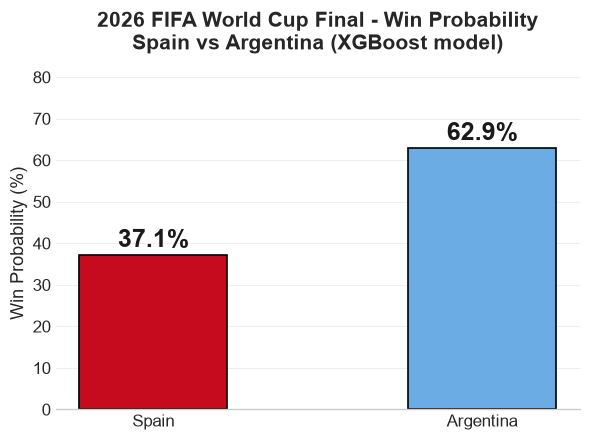

In [99]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(6, 4.5))  # au lieu de (8, 6)

teams = ['Spain', 'Argentina']
probas = [proba_spain_win * 100, proba_argentina_win * 100]
colors = ['#C60B1E', '#6CACE4']  # rouge Espagne officiel, bleu ciel Argentine officiel

bars = ax.bar(teams, probas, color=colors, width=0.45, edgecolor='black', linewidth=1.2)

for bar, proba in zip(bars, probas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{proba:.1f}%', ha='center', fontsize=18, fontweight='bold', color='#1a1a1a')

ax.set_ylabel('Win Probability (%)', fontsize=13, fontweight='medium')
ax.set_title('2026 FIFA World Cup Final - Win Probability\nSpain vs Argentina (XGBoost model)', 
              fontsize=15, fontweight='bold', pad=20)
ax.set_ylim(0, 80)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='both', labelsize=12)
ax.grid(axis='y', alpha=0.3)
ax.grid(axis='x', visible=False)

plt.tight_layout()
plt.savefig('../outputs/final_prediction.png', dpi=200, bbox_inches='tight')
plt.show()

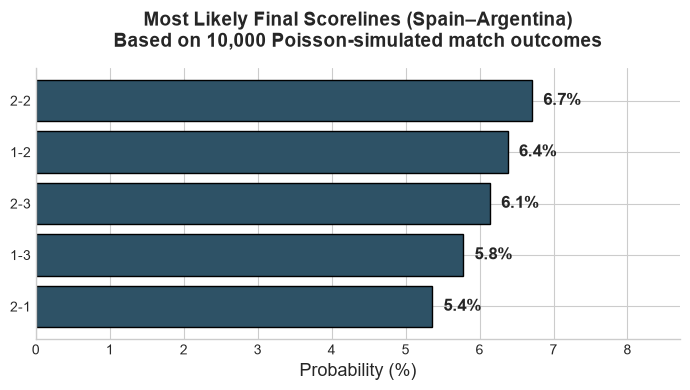

In [100]:
fig, ax = plt.subplots(figsize=(7, 4))  # au lieu de (9, 5.5)

score_labels = [f"{s[0]}-{s[1]}" for s, c in most_common_scores]
score_counts = [c/n_simulations*100 for s, c in most_common_scores]

bars = ax.barh(score_labels, score_counts, color='#2E5266', edgecolor='black', linewidth=1)
ax.invert_yaxis()

for bar, pct in zip(bars, score_counts):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2, 
             f'{pct:.1f}%', va='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Probability (%)', fontsize=13)
ax.set_title('Most Likely Final Scorelines (Spain–Argentina)\nBased on 10,000 Poisson-simulated match outcomes', 
              fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, max(score_counts) + 2)

plt.tight_layout()
plt.savefig('../outputs/scoreline_prediction.png', dpi=200, bbox_inches='tight')
plt.show()